In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.external_data_encyclopedia import ExternalDataEncyclopedia
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

ed = ExternalDataEncyclopedia(
    external_data_path=Path(r"C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\external_data")
)

In [2]:
exports_folder = Path("dp_export_tests")
areas_export_path: Path = exports_folder / "00_add_areas"
clean_db_export_path: Path = exports_folder / "01_cleanup_db"
identify_facets_export_path: Path = exports_folder / "02_identify_facets"
merge_spectral_export_path : Path = exports_folder / "03_merge_spectral"

In [3]:
from boulder_statistics.refinement_plus.bulk_parse_data_tir_maps import DataTirMaps

data_tir_maps: DataFrame = DataTirMaps.bulk_parse(ed).filter(
    pl.col("facet_shape_model_name") == "g_06310mm_spc_obj_0000n00000_v020.obj"
)

data_tir_maps

facet_num,facet_shape_model_name,band depth 350,band depth 440,slope 1000,ratio 1000,sigma band depth 350,sigma band depth 440,sigma slope 1000,sigma ratio 1000,x,y,z,count
f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32
39996.0,"""g_06310mm_spc_obj_0000n00000_v…",1.001793,1.012313,0.99892,null,0.002749,0.001303,0.001329,null,0.248587,0.12209,0.000353,3
24490.0,"""g_06310mm_spc_obj_0000n00000_v…",1.00246,1.01118,0.999438,null,0.002337,0.000626,0.001007,null,-0.204013,-0.157647,0.038473,3
781.0,"""g_06310mm_spc_obj_0000n00000_v…",1.002843,1.011172,1.002414,null,0.001661,0.000802,0.000729,null,-0.10694,0.13326,0.15539,3
40607.0,"""g_06310mm_spc_obj_0000n00000_v…",1.00275,1.012967,0.99904,null,0.001212,0.000664,0.000774,null,0.208157,0.13271,0.07178,3
19484.0,"""g_06310mm_spc_obj_0000n00000_v…",1.003068,1.012197,0.998161,null,0.001985,0.001306,0.00068,null,-0.212173,0.061133,0.084453,3
…,…,…,…,…,…,…,…,…,…,…,…,…,…
35656.0,"""g_06310mm_spc_obj_0000n00000_v…",1.003645,1.01245,0.996899,null,0.001998,0.001188,0.001045,null,0.243123,-0.08881,-0.030487,3
38672.0,"""g_06310mm_spc_obj_0000n00000_v…",1.002004,1.012163,1.000155,null,0.001877,0.000952,0.000708,null,0.21112,0.042697,0.113167,3
36923.0,"""g_06310mm_spc_obj_0000n00000_v…",1.003547,1.012226,0.9992,null,0.001091,0.000759,0.000604,null,0.27033,-0.02794,0.008447,3


In [ ]:
from boulder_statistics.file_storage_adapters.adapter_custom_classes.PL_obj_data import PLOBJData
from boulder_statistics.lods.lod_cubemap_utils import LODCubemapUtils
from boulder_statistics.steps.utils.Bennu_OBJ_to_LAS_cubemap_generator import BennuOBJToLASCubemapGenerator
from boulder_statistics.steps.utils.Better_polars_3D_expressions import POINT_ATTRS, VERT_ID_COLS, BetterPolars3DExpressions
import igl

from boulder_statistics.steps.utils.projection_plotting import ProjectionPlotting

# https://sbnarchive.psi.edu/pds4/orex/orex.altimetry/data_derived_altimetry_global_models/global_digital_terrain_models/SPCv20/

mesh_path = Path(r"C:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\external_data\bennu_models\g_06310mm_spc_obj_0000n00000_v020.obj")
verts, faces = igl.read_triangle_mesh(mesh_path)

obj_data = PLOBJData(
    verts=pl.LazyFrame(
        verts, schema=POINT_ATTRS).with_row_index("vid"),
    tris=pl.LazyFrame(faces, schema=VERT_ID_COLS)
)

points: pl.LazyFrame = BetterPolars3DExpressions._project_points(
    obj_data.verts)
tris: pl.LazyFrame = BetterPolars3DExpressions._attach_points_to_tris(
    points, obj_data.tris)
tris: pl.LazyFrame = tris.with_columns(
    BetterPolars3DExpressions.get_mean_radius(),
    BetterPolars3DExpressions.get_mean_x().alias("x_tri_mean"),
    BetterPolars3DExpressions.get_mean_y().alias("y_tri_mean"),
    BetterPolars3DExpressions.get_mean_z().alias("z_tri_mean")
)

tris_collected = tris.collect()
tris_collected.head()

c:\Users\Joshu\Documents\AO33_backup\Boulder_database\AO33\.venv\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


0,1,2,x0,y0,z0,posx_u0,posx_v0,posx_N0,negx_u0,negx_v0,negx_N0,posy_u0,posy_v0,posy_N0,negy_u0,negy_v0,negy_N0,posz_u0,posz_v0,posz_N0,negz_u0,negz_v0,negz_N0,x1,y1,z1,posx_u1,posx_v1,posx_N1,negx_u1,negx_v1,negx_N1,posy_u1,posy_v1,posy_N1,negy_u1,negy_v1,negy_N1,posz_u1,posz_v1,posz_N1,negz_u1,negz_v1,negz_N1,x2,y2,z2,posx_u2,posx_v2,posx_N2,negx_u2,negx_v2,negx_N2,posy_u2,posy_v2,posy_N2,negy_u2,negy_v2,negy_N2,posz_u2,posz_v2,posz_N2,negz_u2,negz_v2,negz_N2,r_tri_mean,x_tri_mean,y_tri_mean,z_tri_mean
i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,66,1,-0.11842,0.14876,0.12651,0.101976,0.925215,-0.14876,0.898024,0.925215,0.14876,-0.087938,0.031974,0.12651,-0.087938,0.968026,-0.12651,-0.128103,1.034158,0.11842,1.128103,1.034158,-0.11842,-0.11661,0.1466,0.12951,0.102285,0.941712,-0.1466,0.897715,0.941712,0.1466,-0.065979,0.049803,0.12951,-0.065979,0.950197,-0.12951,-0.128591,1.055313,0.11661,1.128591,1.055313,-0.11661,-0.11587,0.14976,0.1274,0.113148,0.925347,-0.14976,0.886852,0.925347,0.14976,-0.087755,0.045251,0.1274,-0.087755,0.954749,-0.1274,-0.146241,1.049754,0.11587,1.146241,1.049754,-0.11587,0.228102,-0.116967,0.148373,0.127807
0,65,66,-0.11842,0.14876,0.12651,0.101976,0.925215,-0.14876,0.898024,0.925215,0.14876,-0.087938,0.031974,0.12651,-0.087938,0.968026,-0.12651,-0.128103,1.034158,0.11842,1.128103,1.034158,-0.11842,-0.11978,0.14656,0.1274,0.091362,0.934634,-0.14656,0.908638,0.934634,0.14656,-0.075196,0.029906,0.1274,-0.075196,0.970094,-0.1274,-0.111788,1.031808,0.11978,1.111788,1.031808,-0.11978,-0.11661,0.1466,0.12951,0.102285,0.941712,-0.1466,0.897715,0.941712,0.1466,-0.065979,0.049803,0.12951,-0.065979,0.950197,-0.12951,-0.128591,1.055313,0.11661,1.128591,1.055313,-0.11661,0.228082,-0.11827,0.147307,0.127807
65,131,66,-0.11978,0.14656,0.1274,0.091362,0.934634,-0.14656,0.908638,0.934634,0.14656,-0.075196,0.029906,0.1274,-0.075196,0.970094,-0.1274,-0.111788,1.031808,0.11978,1.111788,1.031808,-0.11978,-0.11856,0.14337,0.13172,0.086524,0.959371,-0.14337,0.913476,0.959371,0.14337,-0.044223,0.049954,0.13172,-0.044223,0.950046,-0.13172,-0.104631,1.055499,0.11856,1.104631,1.055499,-0.11856,-0.11661,0.1466,0.12951,0.102285,0.941712,-0.1466,0.897715,0.941712,0.1466,-0.065979,0.049803,0.12951,-0.065979,0.950197,-0.12951,-0.128591,1.055313,0.11661,1.128591,1.055313,-0.11661,0.227933,-0.118317,0.14551,0.129543
65,130,131,-0.11978,0.14656,0.1274,0.091362,0.934634,-0.14656,0.908638,0.934634,0.14656,-0.075196,0.029906,0.1274,-0.075196,0.970094,-0.1274,-0.111788,1.031808,0.11978,1.111788,1.031808,-0.11978,-0.12191,0.14311,0.12908,0.074069,0.950982,-0.14311,0.925931,0.950982,0.14311,-0.054346,0.027773,0.12908,-0.054346,0.972227,-0.12908,-0.086949,1.029407,0.12191,1.086949,1.029407,-0.12191,-0.11856,0.14337,0.13172,0.086524,0.959371,-0.14337,0.913476,0.959371,0.14337,-0.044223,0.049954,0.13172,-0.044223,0.950046,-0.13172,-0.104631,1.055499,0.11856,1.104631,1.055499,-0.11856,0.228036,-0.120083,0.144347,0.1294
130,196,131,-0.12191,0.14311,0.12908,0.074069,0.950982,-0.14311,0.925931,0.950982,0.14311,-0.054346,0.027773,0.12908,-0.054346,0.972227,-0.12908,-0.086949,1.029407,0.12191,1.086949,1.029407,-0.12191,-0.12094,0.13951,0.13393,0.066554,0.980001,-0.13951,0.933446,0.980001,0.13951,-0.020832,0.048495,0.13393,-0.020832,0.951505,-0.13393,-0.076774,1.053704,0.12094,1.076774,1.053704,-0.12094,-0.11856,0.14337,0.13172,0.086524,0.959371,-0.14337,0.913476,0.959371,0.14337,-0.044223,0.049954,0.13172,-0.044223,0.950046,-0.13172,-0.104631,1.055499,0.11856,1.104631,1.055499,-0.11856,0.22801,-0.12047,0.141997,0.131577


In [ ]:
from typing import List
from tqdm import tqdm
from scipy.spatial import cKDTree

closest_facets_dfs : List[DataFrame] = []

facets_xyz = (
        data_tir_maps
        .select(["x", "y", "z"])
        .to_numpy()
        .astype(np.float32)
    )

tris_xyz = (
    tris_collected
    .select(["x_tri_mean", "y_tri_mean", "z_tri_mean"])
    .to_numpy()
    .astype(np.float32)
)

chunk_tree = cKDTree(facets_xyz)

distance, idx = chunk_tree.query(
    tris_xyz,
    k=1,
    workers=-1,
)

facet_nums = data_tir_maps["facet_num"].to_numpy()

# valid nearest neighbours
valid = idx < len(facet_nums)

nearest_facet_num = np.full(len(idx), np.nan)
nearest_facet_num = facet_nums[idx[valid]]

tris_collected_with_facets = tris_collected.with_columns(
    pl.Series("facet_num", nearest_facet_num),
    pl.Series("face_center_from_facet_center", distance)
)

tris_collected_with_facets.head()

0,1,2,x0,y0,z0,posx_u0,posx_v0,posx_N0,negx_u0,negx_v0,negx_N0,posy_u0,posy_v0,posy_N0,negy_u0,negy_v0,negy_N0,posz_u0,posz_v0,posz_N0,negz_u0,negz_v0,negz_N0,x1,y1,z1,posx_u1,posx_v1,posx_N1,negx_u1,negx_v1,negx_N1,posy_u1,posy_v1,posy_N1,negy_u1,negy_v1,negy_N1,posz_u1,posz_v1,posz_N1,negz_u1,negz_v1,negz_N1,x2,y2,z2,posx_u2,posx_v2,posx_N2,negx_u2,negx_v2,negx_N2,posy_u2,posy_v2,posy_N2,negy_u2,negy_v2,negy_N2,posz_u2,posz_v2,posz_N2,negz_u2,negz_v2,negz_N2,r_tri_mean,x_tri_mean,y_tri_mean,z_tri_mean,facet_num,face_center_from_facet_center
i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,66,1,-0.11842,0.14876,0.12651,0.101976,0.925215,-0.14876,0.898024,0.925215,0.14876,-0.087938,0.031974,0.12651,-0.087938,0.968026,-0.12651,-0.128103,1.034158,0.11842,1.128103,1.034158,-0.11842,-0.11661,0.1466,0.12951,0.102285,0.941712,-0.1466,0.897715,0.941712,0.1466,-0.065979,0.049803,0.12951,-0.065979,0.950197,-0.12951,-0.128591,1.055313,0.11661,1.128591,1.055313,-0.11661,-0.11587,0.14976,0.1274,0.113148,0.925347,-0.14976,0.886852,0.925347,0.14976,-0.087755,0.045251,0.1274,-0.087755,0.954749,-0.1274,-0.146241,1.049754,0.11587,1.146241,1.049754,-0.11587,0.228102,-0.116967,0.148373,0.127807,0.0,3.3320e-8
0,65,66,-0.11842,0.14876,0.12651,0.101976,0.925215,-0.14876,0.898024,0.925215,0.14876,-0.087938,0.031974,0.12651,-0.087938,0.968026,-0.12651,-0.128103,1.034158,0.11842,1.128103,1.034158,-0.11842,-0.11978,0.14656,0.1274,0.091362,0.934634,-0.14656,0.908638,0.934634,0.14656,-0.075196,0.029906,0.1274,-0.075196,0.970094,-0.1274,-0.111788,1.031808,0.11978,1.111788,1.031808,-0.11978,-0.11661,0.1466,0.12951,0.102285,0.941712,-0.1466,0.897715,0.941712,0.1466,-0.065979,0.049803,0.12951,-0.065979,0.950197,-0.12951,-0.128591,1.055313,0.11661,1.128591,1.055313,-0.11661,0.228082,-0.11827,0.147307,0.127807,1.0,2.6863e-8
65,131,66,-0.11978,0.14656,0.1274,0.091362,0.934634,-0.14656,0.908638,0.934634,0.14656,-0.075196,0.029906,0.1274,-0.075196,0.970094,-0.1274,-0.111788,1.031808,0.11978,1.111788,1.031808,-0.11978,-0.11856,0.14337,0.13172,0.086524,0.959371,-0.14337,0.913476,0.959371,0.14337,-0.044223,0.049954,0.13172,-0.044223,0.950046,-0.13172,-0.104631,1.055499,0.11856,1.104631,1.055499,-0.11856,-0.11661,0.1466,0.12951,0.102285,0.941712,-0.1466,0.897715,0.941712,0.1466,-0.065979,0.049803,0.12951,-0.065979,0.950197,-0.12951,-0.128591,1.055313,0.11661,1.128591,1.055313,-0.11661,0.227933,-0.118317,0.14551,0.129543,2.0,2.1073e-8
65,130,131,-0.11978,0.14656,0.1274,0.091362,0.934634,-0.14656,0.908638,0.934634,0.14656,-0.075196,0.029906,0.1274,-0.075196,0.970094,-0.1274,-0.111788,1.031808,0.11978,1.111788,1.031808,-0.11978,-0.12191,0.14311,0.12908,0.074069,0.950982,-0.14311,0.925931,0.950982,0.14311,-0.054346,0.027773,0.12908,-0.054346,0.972227,-0.12908,-0.086949,1.029407,0.12191,1.086949,1.029407,-0.12191,-0.11856,0.14337,0.13172,0.086524,0.959371,-0.14337,0.913476,0.959371,0.14337,-0.044223,0.049954,0.13172,-0.044223,0.950046,-0.13172,-0.104631,1.055499,0.11856,1.104631,1.055499,-0.11856,0.228036,-0.120083,0.144347,0.1294,3.0,1.4901e-8
130,196,131,-0.12191,0.14311,0.12908,0.074069,0.950982,-0.14311,0.925931,0.950982,0.14311,-0.054346,0.027773,0.12908,-0.054346,0.972227,-0.12908,-0.086949,1.029407,0.12191,1.086949,1.029407,-0.12191,-0.12094,0.13951,0.13393,0.066554,0.980001,-0.13951,0.933446,0.980001,0.13951,-0.020832,0.048495,0.13393,-0.020832,0.951505,-0.13393,-0.076774,1.053704,0.12094,1.076774,1.053704,-0.12094,-0.11856,0.14337,0.13172,0.086524,0.959371,-0.14337,0.913476,0.959371,0.14337,-0.044223,0.049954,0.13172,-0.044223,0.950046,-0.13172,-0.104631,1.055499,0.11856,1.104631,1.055499,-0.11856,0.22801,-0.12047,0.141997,0.131577,4.0,1.4901e-8


In [8]:
tris_to_draw = tris_collected_with_facets.join(
    data_tir_maps,
    on = "facet_num"
)

tris_to_draw.head()

0,1,2,x0,y0,z0,posx_u0,posx_v0,posx_N0,negx_u0,negx_v0,negx_N0,posy_u0,posy_v0,posy_N0,negy_u0,negy_v0,negy_N0,posz_u0,posz_v0,posz_N0,negz_u0,negz_v0,negz_N0,x1,y1,z1,posx_u1,posx_v1,posx_N1,negx_u1,negx_v1,negx_N1,posy_u1,posy_v1,posy_N1,negy_u1,…,posx_u2,posx_v2,posx_N2,negx_u2,negx_v2,negx_N2,posy_u2,posy_v2,posy_N2,negy_u2,negy_v2,negy_N2,posz_u2,posz_v2,posz_N2,negz_u2,negz_v2,negz_N2,r_tri_mean,x_tri_mean,y_tri_mean,z_tri_mean,facet_num,face_center_from_facet_center,facet_shape_model_name,band depth 350,band depth 440,slope 1000,ratio 1000,sigma band depth 350,sigma band depth 440,sigma slope 1000,sigma ratio 1000,x,y,z,count
i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32
18906,18972,18907,0.25117,0.11845,0.00211,1.560236,0.508907,-0.11845,-0.560236,0.508907,0.11845,-27.568721,60.01896,0.00211,-27.568721,-59.01896,-0.00211,0.264204,0.5042,-0.25117,0.735796,0.5042,0.25117,0.24703,0.12376,-0.00323,1.49802,0.486951,-0.12376,-0.49802,0.486951,0.12376,-18.657895,38.73994,-0.00323,-18.657895,…,1.497743,0.508786,-0.12406,-0.497743,0.508786,0.12406,-27.954127,57.279813,0.00218,-27.954127,-56.279813,-0.00218,0.249434,0.504403,-0.24756,0.750566,0.504403,0.24756,0.27695,0.248587,0.12209,0.000353,39996.0,1.6660e-8,"""g_06310mm_spc_obj_0000n00000_v…",1.001793,1.012313,0.99892,null,0.002749,0.001303,0.001329,null,0.248587,0.12209,0.000353,3
9878,9943,5590,-0.20494,-0.15599,0.04027,-0.156901,0.629079,0.15599,1.156901,0.629079,-0.15599,2.436802,-2.044574,0.04027,2.436802,3.044574,-0.04027,0.880575,0.598248,0.20494,0.119425,0.598248,-0.20494,-0.20703,-0.15722,0.03609,-0.158409,0.614775,0.15722,1.158409,0.614775,-0.15722,2.678166,-2.368246,0.03609,2.678166,…,-0.126276,0.622269,0.15973,1.126276,0.622269,-0.15973,2.544675,-2.06106,0.03906,2.544675,3.06106,-0.03906,0.899185,0.597616,0.20007,0.100815,0.597616,-0.20007,0.26068,-0.204013,-0.157647,0.038473,24490.0,1.5360e-8,"""g_06310mm_spc_obj_0000n00000_v…",1.00246,1.01118,0.999438,null,0.002337,0.000626,0.001007,null,-0.204013,-0.157647,0.038473,3
396,461,462,-0.1071,0.13555,0.15338,0.104943,1.065769,-0.13555,0.895057,1.065769,0.13555,0.058124,0.150867,0.15338,0.058124,0.849133,-0.15338,-0.13282,1.21606,0.1071,1.13282,1.21606,-0.1071,-0.10905,0.1313,0.15519,0.08473,1.090975,-0.1313,0.91527,1.090975,0.1313,0.07697,0.148657,0.15519,0.07697,…,0.106297,1.092793,-0.13293,0.893703,1.092793,0.13293,0.078268,0.167925,0.1576,0.078268,0.832075,-0.1576,-0.134996,1.252842,0.10467,1.134996,1.252842,-0.10467,0.230956,-0.10694,0.13326,0.15539,781.0,3.3320e-8,"""g_06310mm_spc_obj_0000n00000_v…",1.002843,1.011172,1.002414,null,0.001661,0.000802,0.000729,null,-0.10694,0.13326,0.15539,3
17937,18001,18002,0.20593,0.13344,0.07488,1.27162,0.780576,-0.13344,-0.27162,0.780576,0.13344,-0.391026,1.875067,0.07488,-0.391026,-0.875067,-0.07488,0.176006,0.681809,-0.20593,0.823994,0.681809,0.20593,0.21064,0.12968,0.07032,1.312153,0.771129,-0.12968,-0.312153,0.771129,0.12968,-0.42207,1.997725,0.07032,-0.42207,…,1.269943,0.759759,-0.13501,-0.269943,0.759759,0.13501,-0.462432,1.982036,0.07014,-0.462432,-0.982036,-0.07014,0.175301,0.668687,-0.2079,0.824699,0.668687,0.2079,0.257087,0.208157,0.13271,0.07178,40607.0,0.0,"""g_06310mm_spc_obj_0000n00000_v…",1.00275,1.012967,0.99904,null,0.001212,0.000664,0.000774,null,0.208157,0.13271,0.07178,3
9384,9450,9385,-0.20934,0.06409,0.08522,-1.133172,1.164846,-0.06409,2.133172,1.164846,0.06409,0.123973,-0.728233,0.08522,0.123973,1.728233,-0.08522,0.346924,0.703544,0.20934,0.653076,0.703544,-0.20934,-0.21547,0.06031,0.08171,-1.286354,1.177417,-0.06031,2.286354,1.177417,0.06031,0.130951,-0.818504,0.08171,0.130951,…,-1.294153,1.232458,-0.059,2.294153,1.232458,0.059,0.158683,-0.724748,0.08643,0.158683,1.724748,-0.08643,0.360658,0.704124,0.21171

In [12]:
arr = ProjectionPlotting.rasterize_tris(
        points, tris_to_draw.lazy(), "posx", colour_column_name=lambda face: f'band depth 350')

plt.imshow(arr, origin="lower")

In [ ]:
data_tir_maps_for_mesh = data_tir_maps.filter(
    pl.col("facet_shape_model_name") == "g_06310mm_spc_obj_0000n00000_v020.obj"
    ).group_by("facet_num").agg()
data_tir_maps_for_mesh

facet_num
f64
30218.0
25872.0
9953.0
40950.0
44738.0
…
48694.0
27292.0
3842.0


In [ ]:
tris.collect()

0,1,2,x0,y0,z0,posx_u0,posx_v0,posx_N0,negx_u0,negx_v0,negx_N0,posy_u0,posy_v0,posy_N0,negy_u0,negy_v0,negy_N0,posz_u0,posz_v0,posz_N0,negz_u0,negz_v0,negz_N0,x1,y1,z1,posx_u1,posx_v1,posx_N1,negx_u1,negx_v1,negx_N1,posy_u1,posy_v1,posy_N1,negy_u1,negy_v1,negy_N1,posz_u1,posz_v1,posz_N1,negz_u1,negz_v1,negz_N1,x2,y2,z2,posx_u2,posx_v2,posx_N2,negx_u2,negx_v2,negx_N2,posy_u2,posy_v2,posy_N2,negy_u2,negy_v2,negy_N2,posz_u2,posz_v2,posz_N2,negz_u2,negz_v2,negz_N2,r_tri_mean,x_tri_mean,y_tri_mean,z_tri_mean
i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,66,1,-0.11842,0.14876,0.12651,0.101976,0.925215,-0.14876,0.898024,0.925215,0.14876,-0.087938,0.031974,0.12651,-0.087938,0.968026,-0.12651,-0.128103,1.034158,0.11842,1.128103,1.034158,-0.11842,-0.11661,0.1466,0.12951,0.102285,0.941712,-0.1466,0.897715,0.941712,0.1466,-0.065979,0.049803,0.12951,-0.065979,0.950197,-0.12951,-0.128591,1.055313,0.11661,1.128591,1.055313,-0.11661,-0.11587,0.14976,0.1274,0.113148,0.925347,-0.14976,0.886852,0.925347,0.14976,-0.087755,0.045251,0.1274,-0.087755,0.954749,-0.1274,-0.146241,1.049754,0.11587,1.146241,1.049754,-0.11587,0.228102,-0.116967,0.148373,0.127807
0,65,66,-0.11842,0.14876,0.12651,0.101976,0.925215,-0.14876,0.898024,0.925215,0.14876,-0.087938,0.031974,0.12651,-0.087938,0.968026,-0.12651,-0.128103,1.034158,0.11842,1.128103,1.034158,-0.11842,-0.11978,0.14656,0.1274,0.091362,0.934634,-0.14656,0.908638,0.934634,0.14656,-0.075196,0.029906,0.1274,-0.075196,0.970094,-0.1274,-0.111788,1.031808,0.11978,1.111788,1.031808,-0.11978,-0.11661,0.1466,0.12951,0.102285,0.941712,-0.1466,0.897715,0.941712,0.1466,-0.065979,0.049803,0.12951,-0.065979,0.950197,-0.12951,-0.128591,1.055313,0.11661,1.128591,1.055313,-0.11661,0.228082,-0.11827,0.147307,0.127807
65,131,66,-0.11978,0.14656,0.1274,0.091362,0.934634,-0.14656,0.908638,0.934634,0.14656,-0.075196,0.029906,0.1274,-0.075196,0.970094,-0.1274,-0.111788,1.031808,0.11978,1.111788,1.031808,-0.11978,-0.11856,0.14337,0.13172,0.086524,0.959371,-0.14337,0.913476,0.959371,0.14337,-0.044223,0.049954,0.13172,-0.044223,0.950046,-0.13172,-0.104631,1.055499,0.11856,1.104631,1.055499,-0.11856,-0.11661,0.1466,0.12951,0.102285,0.941712,-0.1466,0.897715,0.941712,0.1466,-0.065979,0.049803,0.12951,-0.065979,0.950197,-0.12951,-0.128591,1.055313,0.11661,1.128591,1.055313,-0.11661,0.227933,-0.118317,0.14551,0.129543
65,130,131,-0.11978,0.14656,0.1274,0.091362,0.934634,-0.14656,0.908638,0.934634,0.14656,-0.075196,0.029906,0.1274,-0.075196,0.970094,-0.1274,-0.111788,1.031808,0.11978,1.111788,1.031808,-0.11978,-0.12191,0.14311,0.12908,0.074069,0.950982,-0.14311,0.925931,0.950982,0.14311,-0.054346,0.027773,0.12908,-0.054346,0.972227,-0.12908,-0.086949,1.029407,0.12191,1.086949,1.029407,-0.12191,-0.11856,0.14337,0.13172,0.086524,0.959371,-0.14337,0.913476,0.959371,0.14337,-0.044223,0.049954,0.13172,-0.044223,0.950046,-0.13172,-0.104631,1.055499,0.11856,1.104631,1.055499,-0.11856,0.228036,-0.120083,0.144347,0.1294
130,196,131,-0.12191,0.14311,0.12908,0.074069,0.950982,-0.14311,0.925931,0.950982,0.14311,-0.054346,0.027773,0.12908,-0.054346,0.972227,-0.12908,-0.086949,1.029407,0.12191,1.086949,1.029407,-0.12191,-0.12094,0.13951,0.13393,0.066554,0.980001,-0.13951,0.933446,0.980001,0.13951,-0.020832,0.048495,0.13393,-0.020832,0.951505,-0.13393,-0.076774,1.053704,0.12094,1.076774,1.053704,-0.12094,-0.11856,0.14337,0.13172,0.086524,0.959371,-0.14337,0.913476,0.959371,0.14337,-0.044223,0.049954,0.13172,-0.044223,0.950046,-0.13172,-0.104631,1.055499,0.11856,1.104631,1.055499,-0.11856,0.22801,-0.12047,0.141997,0.131577
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
25153,25218,21122,0.15912,0.10759,-0.14547,1.239474,-0.17603

array([[-0.13429333, -0.13429333, -0.13429333, ...,  0.13722333,
         0.13946334,  0.13946334],
       [-0.13429333, -0.13429333, -0.13429333, ...,  0.13722333,
         0.13946334,  0.13946334],
       [-0.13429333, -0.13429333, -0.13429333, ...,  0.13722333,
         0.13946334,  0.13946334],
       ...,
       [-0.13118   , -0.13118   , -0.13118   , ...,  0.13135333,
         0.13135333,  0.13135333],
       [-0.13118   , -0.13118   , -0.13118   , ...,  0.13135333,
         0.13135333,  0.13135333],
       [-0.13118   , -0.13118   , -0.13118   , ...,  0.13135333,
         0.13135333,  0.13135333]], shape=(1024, 1024))

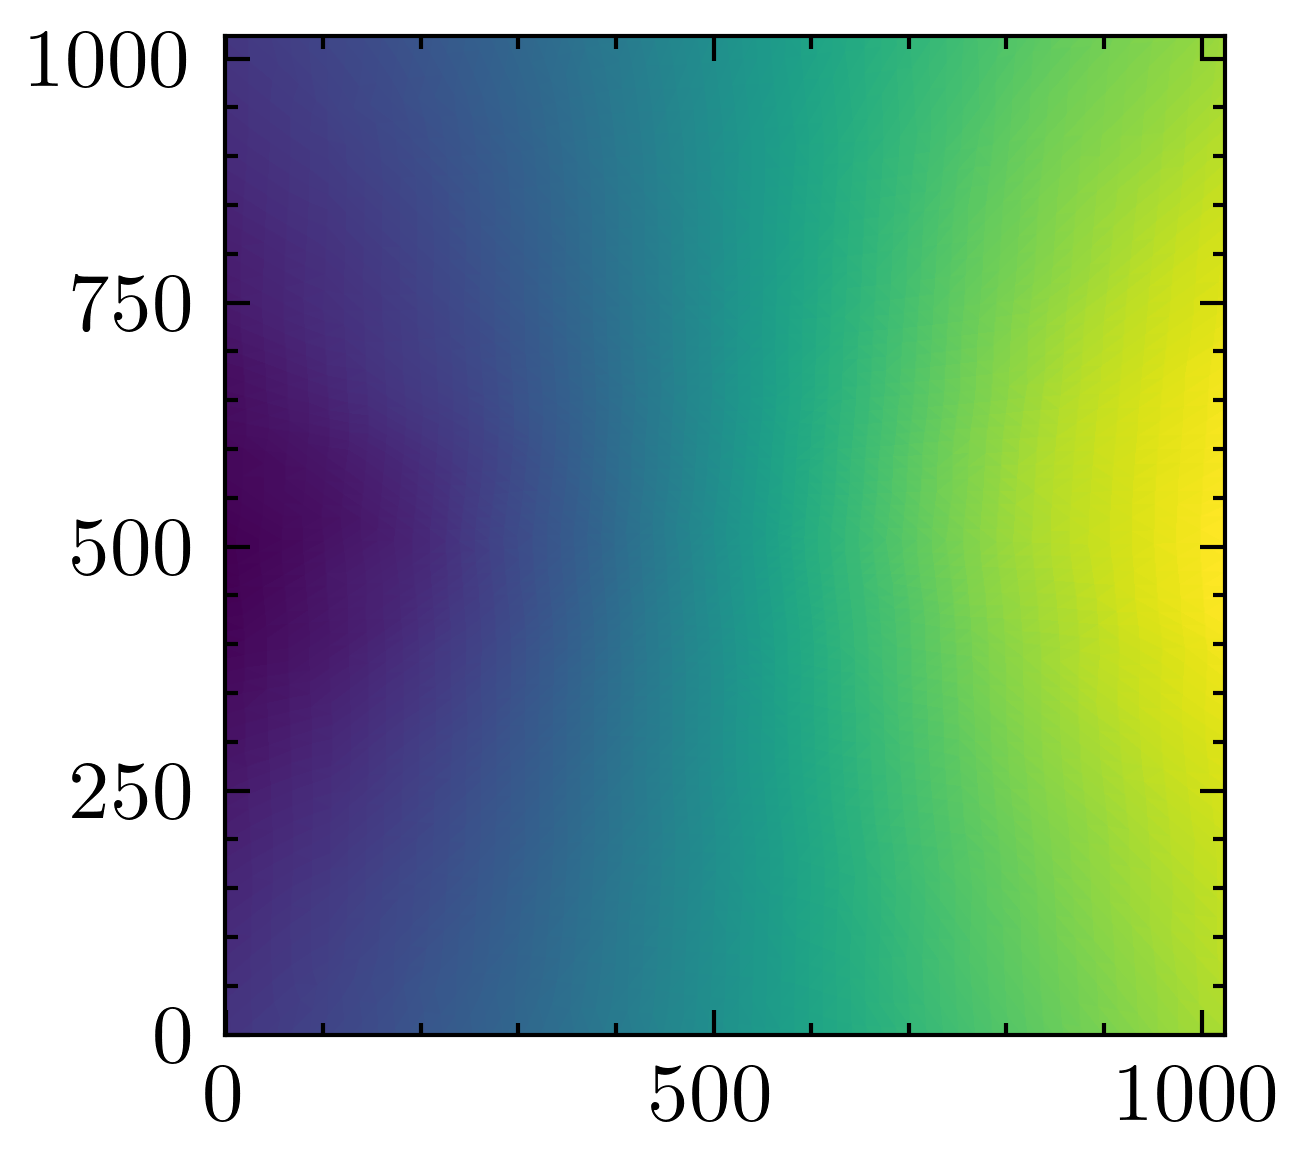

In [ ]:
arr = ProjectionPlotting.rasterize_tris(
        points, tris, "posx", colour_column_name=lambda face: f'x_tri_mean')

# plt.imshow(arr, origin="lower")
# plt.colorbar(label="Band depth")
# plt.title("Band Depth 350")
# plt.xlabel("X")
# plt.ylabel("Y")

# https://sbnarchive.psi.edu/pds4/orex/orex.altimetry/data_derived_altimetry_global_models/global_digital_terrain_models/SPCv20/

# tris.collect()

plt.imshow(arr, origin="lower")
arr

In [ ]:
# data_tir_maps_full = pl.read_parquet(
#     identify_facets_export_path
#     ).with_columns(
#     x = pl.col("x_hat") * pl.col("radius"),
#     y = pl.col("y_hat") * pl.col("radius"),
#     z = pl.col("z_hat") * pl.col("radius")
# ).filter(
#     pl.col("sigma") != -9999.0
# ).with_columns(
#     radius = 0.628 * 1e-3
# )

# data_tir_maps_full

In [ ]:
# band_depth_350: DataFrame = data_tir_maps_full.filter(pl.col("band depth 350").is_not_null())
# band_depth_440: DataFrame = data_tir_maps_full.filter(pl.col("band depth 440").is_not_null())
# slope_1000: DataFrame = data_tir_maps_full.filter(pl.col("slope 1000").is_not_null())
# ratio_1000: DataFrame = data_tir_maps_full.filter(pl.col("ratio 1000").is_not_null())

In [ ]:
# current_db: LazyFrame = pl.scan_parquet(
#     clean_db_export_path
#     ).select(
#         "face", "i", "j",
#         "x", "y", "z"
#     )

In [ ]:
# from polars.expr.expr import Expr
# from tqdm import tqdm

# from boulder_statistics.refinement_plus.bounding_box import BoundingBox
# from boulder_statistics.refinement_plus.qcube_chunk import QCubeChunk
# from boulder_statistics.refinement_plus.refinement_chunking import ChunkingTools
# from boulder_statistics.refinement_plus.refinement_tools import restrict_by_clipped_sigma_log_space
# from scipy.spatial import cKDTree

# for chunk in QCubeChunk.generate(1):
#     chunk_bbox: BoundingBox = ChunkingTools.get_chunk_bbox(current_db, chunk)
#     chunk_center_x, chunk_center_y, chunk_center_z = chunk_bbox.center
#     chunk_box_bounding_sphere = chunk_bbox.bounding_sphere_radius

#     delta_x: Expr = (pl.col("x") - chunk_center_x)
#     delta_y: Expr = (pl.col("y") - chunk_center_y)
#     delta_z: Expr = (pl.col("z") - chunk_center_z)
#     delta_r_sqr: Expr = (delta_x ** 2 + delta_y ** 2 + delta_z ** 2)
#     to_consider: Expr = delta_r_sqr < (chunk_box_bounding_sphere + pl.col("radius")) ** 2

#     band_depth_350_to_consider: DataFrame = band_depth_350.select(
#         "band depth 350", "sigma", "radius", "x", "y", "z"
#     ).filter(
#         to_consider
#     )

#     xs, ys, zs = ChunkingTools.extract_chunks(
#         current_db, chunk, ["x", "y", "z"])
    
#     chunk_shape = xs.shape

#     points = np.column_stack([
#         xs.ravel(),
#         ys.ravel(),
#         zs.ravel()
#     ])

#     tree = cKDTree(points)
    
#     # Weights are 1 / (sigma  ** 2)
#     band_depth_350_weights_vals_arr = np.zeros_like(xs, dtype=np.float64).ravel()
#     band_depth_350_weights_arr = np.zeros_like(xs, dtype=np.float64).ravel()
    
#     for facet_center_x, facet_center_y, facet_center_z, facet_radius, facet_val, facet_sigma in tqdm(
#         band_depth_350_to_consider.select(
#         ["x", "y", "z", "radius", "band depth 350", "sigma"]).iter_rows(),
#         total = band_depth_350_to_consider.height):

#         facet_weight = 1 / (facet_sigma ** 2)

#         idx = np.asarray(tree.query_ball_point(
#             [facet_center_x, facet_center_y, facet_center_z],
#             facet_radius
#         ))

#         if len(idx) == 0: continue

#         band_depth_350_weights_vals_arr[idx] += facet_val * facet_weight
#         band_depth_350_weights_arr[idx] += facet_weight

#     band_depth_350_val = (band_depth_350_weights_vals_arr / band_depth_350_weights_arr).reshape(
#         chunk_shape)
#     band_depth_350_sigma = (1 / np.sqrt(band_depth_350_weights_arr)).reshape(
#         chunk_shape)
    
#     break

In [ ]:
# import matplotlib.pyplot as plt

# plt.imshow(band_depth_350_val, origin="lower")
# plt.colorbar(label="Band depth")
# plt.title("Band Depth 350")
# plt.xlabel("X")
# plt.ylabel("Y")
# plt.show()

# # https://sbnarchive.psi.edu/pds4/orex/orex.altimetry/data_derived_altimetry_global_models/global_digital_terrain_models/SPCv20/

In [ ]:
# from polars.expr.expr import Expr
# from tqdm import tqdm

# from boulder_statistics.refinement_plus.bounding_box import BoundingBox
# from boulder_statistics.refinement_plus.qcube_chunk import QCubeChunk
# from boulder_statistics.refinement_plus.refinement_chunking import ChunkingTools
# from boulder_statistics.refinement_plus.refinement_tools import restrict_by_clipped_sigma_log_space

# for chunk in QCubeChunk.generate(3):
#     chunk_bbox: BoundingBox = ChunkingTools.get_chunk_bbox(current_db, chunk)
#     chunk_center_x, chunk_center_y, chunk_center_z = chunk_bbox.center
#     chunk_box_bounding_sphere = chunk_bbox.bounding_sphere_radius

#     delta_x: Expr = (pl.col("x") - chunk_center_x)
#     delta_y: Expr = (pl.col("y") - chunk_center_y)
#     delta_z: Expr = (pl.col("z") - chunk_center_z)
#     delta_r_sqr: Expr = (delta_x ** 2 + delta_y ** 2 + delta_z ** 2)
#     to_consider: Expr = delta_r_sqr < (chunk_box_bounding_sphere + pl.col("radius")) ** 2

#     band_depth_350_to_consider: DataFrame = band_depth_350.select(
#         "band depth 350", "sigma", "radius", "x", "y", "z"
#     ).filter(
#         to_consider
#     )

#     xs, ys, zs = ChunkingTools.extract_chunks(
#         current_db, chunk, ["x", "y", "z"])
    
#     # Weights are 1 / (sigma  ** 2)
#     band_depth_350_weights_vals_arr = np.zeros_like(xs, dtype=np.float64)
#     band_depth_350_weights_arr = np.zeros_like(xs, dtype=np.float64)
    
#     for facet_center_x, facet_center_y, facet_center_z, facet_radius, facet_val, facet_sigma in tqdm(
#         band_depth_350_to_consider.select(
#         ["x", "y", "z", "radius", "band depth 350", "sigma"]).iter_rows(),
#         total = band_depth_350_to_consider.height):

#         facet_weight = 1 / (facet_sigma ** 2)

#         offsets_sqr = (xs - facet_center_x) ** 2 + (ys - facet_center_y) ** 2 + (zs - facet_center_z) ** 2
#         in_facet_mask  = offsets_sqr < (facet_radius ** 2)

#         band_depth_350_weights_vals_arr += facet_val * facet_weight * in_facet_mask
#         band_depth_350_weights_arr += facet_weight * in_facet_mask

#     band_depth_350_val = band_depth_350_weights_vals_arr / band_depth_350_weights_arr
#     band_depth_350_sigma = 1 / np.sqrt(band_depth_350_weights_arr)
#     break

In [ ]:


# def handle_mesh(chunk : QCubeChunk) -> np.ndarray:
#     chunk_bbox: BoundingBox = ChunkingTools.get_chunk_bbox(current_db, chunk)

#     areas: np.ndarray = ChunkingTools.extract_chunks(dp.Phi_mesh, chunk, ["area"])[0]
#     areas *= 1e6 # Convert to m^2
#     areas = restrict_by_clipped_sigma_log_space(areas)

#     return areas

# ChunkingTools.append_by_chunks(
#     dp.combined_atlas,
#     merge_spectral_export_path,
#     "area",
#     handle_mesh
# )